<a href="https://colab.research.google.com/github/JonathanDLCH/Crypto_DataAnalysis/blob/main/2_Exploracion_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 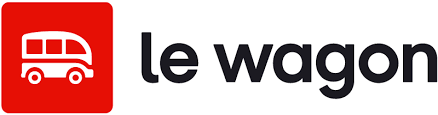

# Semana 1 - Sesión 2: Exploración de Datos

---

## Objetivos de Aprendizaje

Al finalizar esta sesión serás capaz de:

- Crear, indexar y filtrar DataFrames con pandas
- Obtener datos históricos OHLC de criptomonedas
- Manejar errores en peticiones HTTP con try/except y timeout
- Realizar limpieza de datos: tipos, fechas, valores nulos
- Guardar y cargar datos con CSV para persistencia local
- Resamplear datos OHLC a diferentes timeframes (diario → semanal)
- Crear visualizaciones interactivas con Plotly
- Calcular retornos diarios de un activo

## Conceptos Clave

| Concepto | Descripción |
|----------|-------------|
| **DataFrame** | Estructura de datos tabular de pandas |
| **loc/iloc** | Métodos de indexación por etiqueta/posición |
| **dtypes** | Tipos de datos de las columnas |
| **fillna/dropna** | Métodos para manejar valores nulos |
| **try/except** | Manejo de errores en peticiones HTTP |
| **to_csv/read_csv** | Persistencia de datos en formato CSV |
| **resample** | Cambiar la frecuencia temporal de los datos |
| **Retornos** | Cambio porcentual en el precio |

## Conexión con la Sesión Anterior

En la **Sesión 1** aprendimos a:
- Conectarnos a la API de CoinGecko
- Obtener precios actuales y datos desde una API
- Transformar datos de API a DataFrames

Hoy profundizaremos en el análisis de esos datos para prepararnos para construir modelos de Machine Learning.

---

## 1. Setup del Entorno

Instalamos e importamos las librerías necesarias para esta sesión.

In [ ]:
# Install required library
!pip install pycoingecko -q

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# HTTP requests
import requests

# API client
from pycoingecko import CoinGeckoAPI

# Date handling
from datetime import datetime, timedelta

# Display configuration
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
COLORS = {
    'primary': '#F0B90B',
    'secondary': '#1E2329',
    'green': '#0ECB81',
    'red': '#F6465D',
    'gray': '#848E9C',
    'blue': '#1890FF'
}

FIGSIZE_NORMAL = (12, 6)
FIGSIZE_LARGE = (14, 8)
FIGSIZE_DOUBLE = (14, 10)

print("Color palette and figure sizes configured!")

Color palette and figure sizes configured!


---

## 2. DataFrames con Pandas

Un **DataFrame** es la estructura de datos principal de pandas. Es tabular. Esto es como una tabla de Excel o una hoja de cálculo: tiene filas, columnas y permite realizar operaciones de análisis de datos de forma eficiente (element-wise).

### ¿Por qué aprender DataFrames?

- Son la base para manipular datos en Python
- Permiten filtrar, ordenar y transformar datos fácilmente
- Son compatibles con la mayoría de librerías de ML y visualización

### Listas vs Dataframes
Supongamos que tenemos datos de un portafolio crypto:
- quantity: cantidad de cada crypto que tenemos
- unit_price: precio por unidad

#### ENFOQUE 1: Usando Listas (con loop)

In [ ]:
# Create lists for quantities, unit prices, and cryptocurrency symbols
quantities = [0.5, 2.0, 10.0, 100.0]
unit_prices = [97000, 3400, 150, 0.35]
cryptos = ['BTC', 'ETH', 'SOL', 'XRP']

# We can use a loop to calculate total values
total_values = []
for i in range(len(quantities)):
    total = quantities[i] * unit_prices[i]
    total_values.append(total)

print("=== ENFOQUE CON LISTAS ===")
for i in range(len(cryptos)):
    print(f"{cryptos[i]}: {quantities[i]} × ${unit_prices[i]:,} = ${total_values[i]:,.2f}")


=== ENFOQUE CON LISTAS ===
BTC: 0.5 × $97,000 = $48,500.00
ETH: 2.0 × $3,400 = $6,800.00
SOL: 10.0 × $150 = $1,500.00
XRP: 100.0 × $0.35 = $35.00


#### ENFOQUE 2: Usando DataFrames de Pandas (Element-Wise)

In [ ]:
# Create DataFrame with data
portfolio = pd.DataFrame({
    'crypto': ['BTC', 'ETH', 'SOL', 'XRP'],
    'quantity': [0.5, 2.0, 10.0, 100.0],
    'unit_price': [97000, 3400, 150, 0.35]
})

# Create new column element-wise in a single operation
portfolio['total_value'] = portfolio['quantity'] * portfolio['unit_price']
portfolio

,crypto,quantity,unit_price,total_value
0,BTC,0.5000,97000.0000,48500.0000
1,ETH,2.0000,3400.0000,6800.0000
2,SOL,10.0000,150.0000,1500.0000
3,XRP,100.0000,0.3500,35.0000


#### Conclusión: ¿Por qué preferir DataFrames?

El ejemplo anterior demuestra varias ventajas de las operaciones **element-wise**:

| Aspecto | For Loop | DataFrame |
|---------|----------|-----------|
| Líneas de código | 4+ líneas | 1 línea |
| Manejo de índices | Manual (`i`, `range`) | Automático |
| Velocidad | Lento (Python puro) | Rápido (NumPy vectorizado) |

En datasets grandes (miles o millones de filas), la diferencia de rendimiento es significativa. Las operaciones vectorizadas evitan el overhead de iterar fila por fila en Python.

### 2.1 Crear DataFrame desde Diccionario

Este es el método más común para crear DataFrames cuando tienes datos estructurados en Python. Simplemente defines un diccionario donde las **claves** son los nombres de las columnas y los **valores** son listas con los datos de cada columna.

In [ ]:
# Create a DataFrame from a dictionary
data_dict = {
    'symbol': ['BTC', 'ETH', 'SOL', 'ADA'],
    'price': [45000, 2500, 100, 0.5],
    'market_cap_billions': [880, 300, 40, 17]
}

df_crypto = pd.DataFrame(data_dict)

print("DataFrame creado desde diccionario:")
df_crypto

DataFrame creado desde diccionario:


,symbol,price,market_cap_billions
0,BTC,45000.0000,880
1,ETH,2500.0000,300
2,SOL,100.0000,40
3,ADA,0.5000,17


### 2.2 Crear DataFrame desde Lista de Listas

Útil cuando tus datos vienen en formato de filas (cada lista interna es una fila). En este caso, necesitas especificar los nombres de las columnas manualmente con el parámetro `columns`.

In [ ]:
# Create a DataFrame from a list of lists
data_list = [
    ['Bitcoin', 'BTC', 45000],
    ['Ethereum', 'ETH', 2500],
    ['Solana', 'SOL', 100],
    ['Cardano', 'ADA', 0.5]
]

df_from_list = pd.DataFrame(data_list, columns=['name', 'symbol', 'price'])

print("DataFrame creado desde lista de listas:")
df_from_list

DataFrame creado desde lista de listas:


,name,symbol,price
0,Bitcoin,BTC,45000.0000
1,Ethereum,ETH,2500.0000
2,Solana,SOL,100.0000
3,Cardano,ADA,0.5000


### 2.3 Crear DataFrame desde Archivo CSV

El método más común para cargar datos externos. `pd.read_csv()` puede leer archivos locales o URLs directamente. Es el formato estándar para datasets en ciencia de datos.

In [ ]:
# Create a DataFrame from a CSV file
url = "https://raw.githubusercontent.com/Yrzxiong/Bitcoin-Dataset/master/bitcoin_dataset.csv"
df_from_csv = pd.read_csv(url)

print("DataFrame creado desde CSV:")
print(f"Filas: {len(df_from_csv)}, Columnas: {len(df_from_csv.columns)}")
print(f"\nColumnas: {df_from_csv.columns.tolist()}")
df_from_csv.head()

DataFrame creado desde CSV:
Filas: 2906, Columnas: 24

Columnas: ['Date', 'btc_market_price', 'btc_total_bitcoins', 'btc_market_cap', 'btc_trade_volume', 'btc_blocks_size', 'btc_avg_block_size', 'btc_n_orphaned_blocks', 'btc_n_transactions_per_block', 'btc_median_confirmation_time', 'btc_hash_rate', 'btc_difficulty', 'btc_miners_revenue', 'btc_transaction_fees', 'btc_cost_per_transaction_percent', 'btc_cost_per_transaction', 'btc_n_unique_addresses', 'btc_n_transactions', 'btc_n_transactions_total', 'btc_n_transactions_excluding_popular', 'btc_n_transactions_excluding_chains_longer_than_100', 'btc_output_volume', 'btc_estimated_transaction_volume', 'btc_estimated_transaction_volume_usd']


,Date,btc_market_price,btc_total_bitcoins,btc_market_cap,btc_trade_volume,btc_blocks_size,btc_avg_block_size,btc_n_orphaned_blocks,btc_n_transactions_per_block,btc_median_confirmation_time,btc_hash_rate,btc_difficulty,btc_miners_revenue,btc_transaction_fees,btc_cost_per_transaction_percent,btc_cost_per_transaction,btc_n_unique_addresses,btc_n_transactions,btc_n_transactions_total,btc_n_transactions_excluding_popular,btc_n_transactions_excluding_chains_longer_than_100,btc_output_volume,btc_estimated_transaction_volume,btc_estimated_transaction_volume_usd
0,2/17/2010 0:00,0.0000,2043200.0000,0.0000,0.0000,0.0000,0.0002,0,1.0000,0.0000,0.0000,2.5277,0.0000,0.0000,31.7810,0.0000,241,244,41240,244,244,65173.1300,36500.0000,0.0000
1,2/18/2010 0:00,0.0000,2054650.0000,0.0000,0.0000,0.0000,0.0002,0,1.0000,0.0000,0.0000,2.5277,0.0000,0.0000,154.4638,0.0000,234,235,41475,235,235,18911.7400,7413.0000,0.0000
2,2/19/2010 0:00,0.0000,2063600.0000,0.0000,0.0000,0.0000,0.0002,0,1.0000,0.0000,0.0000,2.5277,0.0000,0.0000,1278.5166,0.0000,185,183,41658,183,183,9749.9800,700.0000,0.0000
3,2/20/2010 0:00,0.0000,2074700.0000,0.0000,0.0000,0.0000,0.0002,0,1.0000,0.0000,0.0000,2.5277,0.0000,0.0000,22186.6880,0.0000,224,224,41882,224,224,11150.0300,50.0000,0.0000
4,2/21/2010 0:00,0.0000,2085400.0000,0.0000,0.0000,0.0000,0.0002,0,1.0000,0.0000,0.0000,2.5277,0.0000,0.0000,689.1799,0.0000,218,218,42100,218,218,12266.8300,1553.0000,0.0000


### 2.4 Crear DataFrame desde JSON (API)

Conecta directamente con lo aprendido en la Sesión 1. Las APIs típicamente devuelven datos en formato JSON, que podemos convertir a DataFrame con `pd.DataFrame()`. Esto es fundamental para trabajar con datos en tiempo real.

In [ ]:
# Create a DataFrame from JSON (API response)
# Initialize API client
cg_temp = CoinGeckoAPI()

# The get_price method returns a JSON/dictionary structure
btc_price_json = cg_temp.get_coin_ohlc_by_id(
    id='bitcoin',
    vs_currency='usd',
    days=7
)

print("Respuesta JSON de la API:")
print(btc_price_json)

# # The API automatically returns JSON and turn it into a dict/list which can be converted to a DataFrame
df_from_json = pd.DataFrame(btc_price_json, columns=['timestamp', 'open', 'high', 'low', 'close'])

# df_from_json
# # Convert timestamp (milliseconds) to datetime
df_from_json['timestamp'] = pd.to_datetime(df_from_json['timestamp'], unit='ms')
# df_from_json

# # Ensure OHLC columns are float
ohlc_cols = ['open', 'high', 'low', 'close']
df_from_json[ohlc_cols] = df_from_json[ohlc_cols].astype(float)

# # Set timestamp as index
df_from_json = df_from_json.set_index('timestamp')

df_from_json.head()

Respuesta JSON de la API:
[[1773115200000, 68421.0, 70470.0, 68421.0, 69489.0], [1773129600000, 69450.0, 70438.0, 69450.0, 70396.0], [1773144000000, 70419.0, 71221.0, 70419.0, 70672.0], [1773158400000, 70612.0, 71576.0, 69400.0, 70954.0], [1773172800000, 71385.0, 71612.0, 69832.0, 70007.0], [1773187200000, 70037.0, 70312.0, 69506.0, 69883.0], [1773201600000, 69929.0, 70099.0, 69541.0, 69585.0], [1773216000000, 69558.0, 70186.0, 69526.0, 69686.0], [1773230400000, 69655.0, 69694.0, 69324.0, 69324.0], [1773244800000, 69181.0, 70999.0, 69034.0, 70242.0], [1773259200000, 70259.0, 71230.0, 70259.0, 70692.0], [1773273600000, 70629.0, 70801.0, 70193.0, 70227.0], [1773288000000, 70203.0, 70330.0, 69291.0, 69405.0], [1773302400000, 69437.0, 69833.0, 69265.0, 69833.0], [1773316800000, 69819.0, 70690.0, 69640.0, 70498.0], [1773331200000, 70446.0, 70586.0, 69460.0, 70351.0], [1773345600000, 70311.0, 70462.0, 69832.0, 70453.0], [1773360000000, 70479.0, 70622.0, 70042.0, 70544.0], [1773374400000, 704

,open,high,low,close
timestamp,,,,
2026-03-10 04:00:00,68421.0000,70470.0000,68421.0000,69489.0000
2026-03-10 08:00:00,69450.0000,70438.0000,69450.0000,70396.0000
2026-03-10 12:00:00,70419.0000,71221.0000,70419.0000,70672.0000
2026-03-10 16:00:00,70612.0000,71576.0000,69400.0000,70954.0000
2026-03-10 20:00:00,71385.0000,71612.0000,69832.0000,70007.0000


### Indexación con loc e iloc

Pandas ofrece dos formas principales de acceder a datos:

- **`iloc[]`**: Indexación por **posición** (índice numérico, empezando desde 0)
- **`loc[]`**: Indexación por **etiqueta** (nombre de fila/columna)

#### iloc

El método `iloc` permite acceder a datos por **posición numérica** (índice entero). Es útil cuando:

- Quieres acceder a filas/columnas por su posición (0, 1, 2...)
- No conoces o no quieres usar las etiquetas del índice
- Necesitas hacer slicing como en listas de Python

**Sintaxis:**
```python
df.iloc[filas]              # Seleccionar filas
df.iloc[filas, columnas]    # Seleccionar filas y columnas
df.iloc[:5]                 # Primeras 5 filas (slicing)
df.iloc[0, 2]               # Elemento en fila 0, columna 2
```

[Documentación de iloc](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iloc.html)

In [ ]:
# Indexing with iloc (by numeric position)
print("Primera fila con iloc[0]:")
df_from_json.iloc[0]

Primera fila con iloc[0]:


,2026-03-10 04:00:00
open,68421.0000
high,70470.0000
low,68421.0000
close,69489.0000


In [ ]:
# Indexing to get the first 2 rows (slicing)
print("\nPrimeras 2 filas con iloc[:2]:")
df_from_json.iloc[:2]


Primeras 2 filas con iloc[:2]:


,open,high,low,close
timestamp,,,,
2026-03-10 04:00:00,68421.0000,70470.0000,68421.0000,69489.0000
2026-03-10 08:00:00,69450.0000,70438.0000,69450.0000,70396.0000


In [ ]:
# Accessing a specific element
print("\nElemento en fila 1, columna 1 con iloc[1, 1]:")
df_from_json.iloc[4,3]


Elemento en fila 1, columna 1 con iloc[1, 1]:


np.float64(70007.0)

#### loc

El método `loc` permite acceder a datos por **etiqueta** (nombre del índice/columna). Es útil cuando:

- Conoces el nombre de las filas o columnas que necesitas
- El índice tiene valores significativos (fechas, símbolos, IDs)
- Quieres código más legible y autodocumentado

**Sintaxis:**
```python
df.loc[etiqueta]                    # Seleccionar fila por etiqueta
df.loc[etiqueta, 'columna']         # Seleccionar valor específico
df.loc['2024-01-01':'2024-01-31']   # Rango de fechas (slicing inclusivo)
df.loc[['A', 'B'], ['col1', 'col2']] # Múltiples filas y columnas
```

**Diferencia clave con iloc:** `loc` incluye ambos extremos en slicing, `iloc` excluye el final.

[Documentación de loc](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html)

In [ ]:
# Indexing with loc (by label)
# First, set an index by name
df_crypto_indexed = df_crypto.set_index('symbol')
# print("DataFrame con índice por symbol:")
# display(df_crypto_indexed)
df_crypto_indexed

,price,market_cap_billions
symbol,,
BTC,45000.0000,880
ETH,2500.0000,300
SOL,100.0000,40
ADA,0.5000,17


In [ ]:
# Filter rows by label
print("\nFila de BTC con loc['BTC']:")
# display(df_crypto_indexed.loc['BTC'])
df_crypto_indexed.loc['ETH':]


Fila de BTC con loc['BTC']:


,price,market_cap_billions
symbol,,
ETH,2500.0000,300
SOL,100.0000,40
ADA,0.5000,17


In [ ]:
# Filter multiple rows and select a specific column
print("\nSeleccionar columna 'price' de filas BTC y ETH:")
# display(df_crypto_indexed.loc[['BTC', 'ETH'], 'price'])
df_crypto_indexed.loc['BTC':'ETH', 'price']


Seleccionar columna 'price' de filas BTC y ETH:


,price
symbol,
BTC,45000.0000
ETH,2500.0000


#### Seleccionar columnas

La selección de columnas es una de las operaciones más frecuentes. Hay dos formas principales:

| Sintaxis | Resultado | Uso |
|----------|-----------|-----|
| `df['columna']` | Series | Una sola columna |
| `df[['col1', 'col2']]` | DataFrame | Múltiples columnas |

**Nota importante:**
- Corchetes simples `[]` devuelven una **Series** (1D)
- Corchetes dobles `[[]]` devuelven un **DataFrame** (2D)

Esta diferencia es importante porque algunos métodos solo funcionan con DataFrames y otros solo con Series.

[Documentación de indexación](https://pandas.pydata.org/docs/user_guide/indexing.html#basics)

In [ ]:
# Column selection
print("Seleccionar una columna (devuelve Series):")
type(df_crypto['symbol'])

Seleccionar una columna (devuelve Series):


pandas.core.series.Series

In [ ]:
# Selecting multiple columns
print("\nSeleccionar múltiples columnas (devuelve DataFrame):")
df_crypto[['symbol']]


Seleccionar múltiples columnas (devuelve DataFrame):


,symbol
0,BTC
1,ETH
2,SOL
3,ADA


### Filtrado con Condiciones Booleanas

El filtrado permite seleccionar filas que cumplen ciertas condiciones. Es una de las operaciones más utilizadas en análisis de datos.

In [ ]:
# Filtering with boolean conditions
print("Cryptos con precio mayor a $1,000:")
mask_high_price = df_crypto['price'] > 1000
high_price = df_crypto[mask_high_price]
high_price

Cryptos con precio mayor a $1,000:


,symbol,price,market_cap_billions
0,BTC,45000.0000,880
1,ETH,2500.0000,300


In [ ]:
# Filtering with boolean conditions
print("\nCryptos con market cap mayor a $100B:")
mask_large_cap = df_crypto['market_cap_billions'] > 100
large_cap = df_crypto[mask_large_cap]
large_cap


Cryptos con market cap mayor a $100B:


,symbol,price,market_cap_billions
0,BTC,45000.0000,880
1,ETH,2500.0000,300


In [ ]:
# Filtering with multiple conditions
print("\nCombinar condiciones (precio > 100 Y market_cap > 50B):")
mask_price = df_crypto['price'] > 100
mask_cap = df_crypto['market_cap_billions'] > 50
filtered = df_crypto[mask_price & mask_cap]
filtered


Combinar condiciones (precio > 100 Y market_cap > 50B):


,symbol,price,market_cap_billions
0,BTC,45000.0000,880
1,ETH,2500.0000,300


---

## 3. Obteniendo Datos Históricos

Vamos a obtener **90 días** de datos históricos de Bitcoin. Esto nos dará suficiente información para realizar un análisis significativo.

### ¿Por qué 90 días?

- Suficientes datos para identificar patrones
- Captura diferentes condiciones de mercado
- Ideal para análisis de mediano plazo

Al trabajar con APIs externas, es importante manejar posibles errores de red o del servidor. Veremos cómo hacerlo con `try/except` y `timeout`.

[Documentación de este endpoint de Binance US API](https://docs.binance.us/#get-candlestick-data)

### Buenas prácticas: try/except y timeout en requests

Cuando hacemos peticiones HTTP a APIs externas, muchas cosas pueden salir mal: el servidor puede estar caído, la conexión puede ser lenta, o la URL puede ser incorrecta. Para manejar estos casos, usamos:

- **`timeout`**: Establece un tiempo máximo de espera (en segundos) para la respuesta. Sin timeout, tu programa podría quedarse esperando indefinidamente si el servidor no responde.
- **`try/except`**: Permite capturar errores y manejarlos sin que el programa se detenga abruptamente.
- **`raise_for_status()`**: Lanza una excepción si la respuesta HTTP indica un error (códigos 4xx o 5xx).

**Errores comunes en requests:**

| Excepción | Causa |
|-----------|-------|
| `Timeout` | El servidor no respondió a tiempo |
| `ConnectionError` | No se pudo conectar al servidor |
| `HTTPError` | El servidor respondió con un código de error (404, 500, etc.) |
| `RequestException` | Cualquier otro error de requests (clase base) |

[Documentación de Timeouts](https://requests.readthedocs.io/en/latest/user/quickstart/#timeouts) · [Documentación de Errores y Excepciones](https://requests.readthedocs.io/en/latest/user/quickstart/#errors-and-exceptions)

In [ ]:
# Binance.US API endpoint
url = "https://api.binance.us/api/v3/klines"

# Request parameters
params = {
    "symbol": "BTCUSD",
    "interval": "1d",
    "limit": 90
}

# Send GET request with error handling
try:
    response = requests.get(url, params=params, timeout=10)
    response.raise_for_status()
    btc_ohlc_raw = response.json()
    print(f"Data retrieved successfully! {len(btc_ohlc_raw)} records")
except requests.exceptions.Timeout:
    print("Error: The request timed out. Try again later.")
except requests.exceptions.HTTPError as e:
    print(f"HTTP Error: {e}")
except requests.exceptions.RequestException as e:
    print(f"Request Error: {e}")

Data retrieved successfully! 90 records


In [ ]:
# Convert raw data to DataFrame
df_btc_ohlc_raw = pd.DataFrame(btc_ohlc_raw)
df_btc_ohlc_raw

,0,1,2,3,4,5,6,7,8,9,10,11
0,1766016000000,86156.97000000,89781.07000000,84652.00000000,85474.35000000,10.40421000,1766102399999,905959.71314930,1744,3.99520000,350512.10438310,0
1,1766102400000,85505.14000000,89200.00000000,85225.00000000,88195.62000000,9.66873000,1766188799999,846274.49642650,1214,4.94801000,433875.16620290,0
2,1766188800000,88100.00000000,88523.75000000,87942.16000000,88436.97000000,1.04483000,1766275199999,92174.20306600,221,0.84477000,74540.26708790,0
3,1766275200000,88437.98000000,88945.30000000,87640.71000000,88621.79000000,2.46838000,1766361599999,217948.28100680,548,1.57299000,139035.11703410,0
4,1766361600000,88621.79000000,90438.97000000,87925.44000000,88477.95000000,6.32063000,1766447999999,563655.66748390,1480,2.34763000,210060.17778170,0
...,...,...,...,...,...,...,...,...,...,...,...,...
85,1773360000000,70462.20000000,73862.95000000,70462.20000000,70929.47000000,23.42175000,1773446399999,1685284.20437440,3904,11.36047000,817615.93231760,0
86,1773446400000,70929.47000000,71289.48000000,70361.45000000,71244.33000000,5.73626000,1773532799999,406798.98328160,720,2.08347000,147485.30148930,0
87,1773532800000,71213.39000000,73200.00000000,70900.00000000,72815.50000000,8.94311000,1773619199999,642514.19059070,1581,5.80915000,417474.46530430,0
88,1773619200000,72815.50000000,74898.79000000,72329.97000000,74824.75000000,9.70607000,1773705599999,715537.23506540,2824,6.56624000,484400.43774000,0


In [ ]:
# Select the first five columns (timestamp, open, high, low, close)
df_btc_ohlc = df_btc_ohlc_raw.iloc[:, :5]

In [ ]:
# Convert raw data to DataFrame
df_btc = pd.DataFrame(df_btc_ohlc)
df_btc.columns = ['timestamp', 'open', 'high', 'low', 'close']

# Display first rows
print("DataFrame created successfully!")
df_btc.head()

DataFrame created successfully!


,timestamp,open,high,low,close
0,1766016000000,86156.97000000,89781.07000000,84652.00000000,85474.35000000
1,1766102400000,85505.14000000,89200.00000000,85225.00000000,88195.62000000
2,1766188800000,88100.00000000,88523.75000000,87942.16000000,88436.97000000
3,1766275200000,88437.98000000,88945.30000000,87640.71000000,88621.79000000
4,1766361600000,88621.79000000,90438.97000000,87925.44000000,88477.95000000


---

## 4. Limpieza de Datos

La **limpieza de datos** es un paso crucial antes de cualquier análisis. Datos incorrectos o incompletos pueden llevar a conclusiones erróneas.

### ¿Qué verificamos?

1. **Tipos de datos**: ¿Son correctos los tipos de cada columna?
2. **Fechas**: ¿Están en el formato correcto?
3. **Valores nulos**: ¿Hay datos faltantes?
4. **Valores extremos**: ¿Hay outliers obvios?

### Tipos de datos

#### dtypes

El atributo `dtypes` muestra el tipo de dato de cada columna del DataFrame. Es fundamental verificar los tipos porque:

- **Operaciones matemáticas** requieren tipos numéricos (`int`, `float`)
- **Operaciones de fecha** requieren tipo `datetime`
- **Uso de memoria** varía según el tipo de dato
- **Errores silenciosos** pueden ocurrir si los tipos son incorrectos (ej: sumar strings en lugar de números)

| Tipo | Descripción | Ejemplo |
|------|-------------|---------|
| `int64` | Números enteros | 1, 42, -5 |
| `float64` | Números decimales | 3.14, -0.5 |
| `object` | Texto/strings | 'BTC', 'hello' |
| `datetime64` | Fechas y timestamps | 2024-01-15 |
| `bool` | Valores booleanos | True, False |

[Documentación de dtypes](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html)

In [ ]:
# Verify data types
df_btc.dtypes

,0
timestamp,int64
open,object
high,object
low,object
close,object


#### info()

El método `info()` proporciona un resumen completo del DataFrame incluyendo:

- **Número de filas y columnas** (dimensiones)
- **Nombre de cada columna**
- **Cantidad de valores no nulos** por columna
- **Tipo de dato** de cada columna
- **Uso de memoria** del DataFrame

Es más completo que `dtypes` porque además de los tipos, muestra valores nulos y memoria.

[Documentación de info()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html)

In [ ]:
# Prints a DataFrame summary, including column names, non-null counts, data types, and memory usage
df_btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  90 non-null     int64 
 1   open       90 non-null     object
 2   high       90 non-null     object
 3   low        90 non-null     object
 4   close      90 non-null     object
dtypes: int64(1), object(4)
memory usage: 3.6+ KB


### Conversión de tipo de datos (type casting)

El **type casting** (conversión de tipos) es el proceso de cambiar el tipo de dato de una columna. Esto es necesario cuando:

- Los datos vienen como texto (`object`) pero necesitamos números (`float`, `int`)
- Queremos optimizar el uso de memoria
- Necesitamos realizar operaciones matemáticas

En pandas, usamos el método `astype()` para convertir tipos de datos.

[Documentación de astype()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.astype.html)

In [ ]:
# Check data types
df_btc.dtypes

,0
timestamp,int64
open,object
high,object
low,object
close,object


In [ ]:
# Convert data types with astype()
# Example: convert a column from str to float

# Create a copy for demonstration
df_demo = df_btc.copy()
df_demo['close_float'] = df_btc['close'].astype(float)

# Verify data types after conversion
df_demo.dtypes

,0
timestamp,int64
open,object
high,object
low,object
close,object
close_float,float64


In [ ]:
# Convert multiple columns to float
cols = ['open', 'high', 'low', 'close']
df_btc[cols] = df_btc[cols].astype(float)

In [ ]:
# Verify data types after conversion
df_btc.dtypes

,0
timestamp,int64
open,float64
high,float64
low,float64
close,float64


### Fechas

#### pd.to_datetime()

La función `pd.to_datetime()` convierte argumentos a tipo datetime. Es esencial cuando:

- Los datos de fecha vienen como strings o números (timestamps)
- Necesitas realizar operaciones de tiempo (filtrar por fechas, calcular diferencias)
- Quieres usar el índice temporal para análisis de series de tiempo

**Parámetros principales:**

| Parámetro | Descripción | Ejemplo |
|-----------|-------------|---------|
| `arg` | Valor a convertir (columna, lista, escalar) | `df['fecha']` |
| `unit` | Unidad del timestamp numérico | `'s'` (segundos), `'ms'` (milisegundos) |
| `format` | Formato específico de la fecha string | `'%Y-%m-%d'`, `'%d/%m/%Y'` |
| `errors` | Manejo de errores: `'raise'`, `'coerce'`, `'ignore'` | `'coerce'` convierte errores a NaT |

**Formatos comunes:**

| Código | Significado | Ejemplo |
|--------|-------------|---------|
| `%Y` | Año (4 dígitos) | 2024 |
| `%m` | Mes (01-12) | 01, 12 |
| `%d` | Día (01-31) | 05, 28 |
| `%H` | Hora (00-23) | 14, 23 |
| `%M` | Minuto (00-59) | 30, 59 |
| `%S` | Segundo (00-59) | 45, 00 |

**Sintaxis:**
```python
# Desde timestamp en milisegundos
df['fecha'] = pd.to_datetime(df['timestamp'], unit='ms')

# Desde string con formato específico
df['fecha'] = pd.to_datetime(df['fecha_str'], format='%Y-%m-%d')

# Inferir formato automáticamente
df['fecha'] = pd.to_datetime(df['fecha_str'])
```

[Documentación de pd.to_datetime](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html)

In [ ]:
# Date handling with pd.to_datetime()
# We need column name and time unit
df_btc['timestamp'] = pd.to_datetime(df_btc['timestamp'], unit='ms')

In [ ]:
# Check data types after conversion
df_btc.dtypes

,0
timestamp,datetime64[ns]
open,float64
high,float64
low,float64
close,float64


In [ ]:
# Set timestamp as index
df_btc.set_index('timestamp', inplace=True)

### Guardar datos a CSV

Una vez que los datos están limpios (tipos correctos, fechas convertidas, índice establecido), es buena práctica guardarlos en un archivo **CSV** local. Esto tiene varias ventajas:

- **No depender de la API**: Si la API tiene límites de uso (rate limits) o está caída, puedes trabajar con tus datos locales
- **Reproducibilidad**: Garantiza que siempre trabajas con el mismo dataset
- **Velocidad**: Leer un CSV local es mucho más rápido que hacer una petición HTTP

Pandas ofrece dos métodos complementarios:

| Método | Descripción |
|--------|-------------|
| `df.to_csv('archivo.csv')` | Guarda el DataFrame como archivo CSV |
| `pd.read_csv('archivo.csv')` | Lee un archivo CSV y lo convierte a DataFrame |

**Parámetros útiles de `read_csv`:**

| Parámetro | Descripción | Ejemplo |
|-----------|-------------|---------|
| `index_col` | Columna que será el índice | `'timestamp'` |
| `parse_dates` | Convertir columnas a datetime automáticamente | `True`, `['col1']` |

[Documentación de to_csv()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) · [Documentación de read_csv()](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)

In [ ]:
# Check DataFrame index
df_btc

,open,high,low,close
timestamp,,,,
2025-12-18,86156.9700,89781.0700,84652.0000,85474.3500
2025-12-19,85505.1400,89200.0000,85225.0000,88195.6200
2025-12-20,88100.0000,88523.7500,87942.1600,88436.9700
2025-12-21,88437.9800,88945.3000,87640.7100,88621.7900
2025-12-22,88621.7900,90438.9700,87925.4400,88477.9500
...,...,...,...,...
2026-03-13,70462.2000,73862.9500,70462.2000,70929.4700
2026-03-14,70929.4700,71289.4800,70361.4500,71244.3300
2026-03-15,71213.3900,73200.0000,70900.0000,72815.5000


In [ ]:
# Save clean DataFrame to CSV
df_btc.to_csv('btc_ohlc_90d.csv')
print("Data saved to btc_ohlc_90d.csv")

Data saved to btc_ohlc_90d.csv


In [ ]:
# Read it back to verify
df_btc_from_csv = pd.read_csv('btc_ohlc_90d.csv', index_col='timestamp', parse_dates=True)
print("Data loaded from CSV:")
df_btc_from_csv.head()

Data loaded from CSV:


,open,high,low,close
timestamp,,,,
2025-12-18,86156.9700,89781.0700,84652.0000,85474.3500
2025-12-19,85505.1400,89200.0000,85225.0000,88195.6200
2025-12-20,88100.0000,88523.7500,87942.1600,88436.9700
2025-12-21,88437.9800,88945.3000,87640.7100,88621.7900
2025-12-22,88621.7900,90438.9700,87925.4400,88477.9500


### Valores nulos

#### isnull() / isna()

Los métodos `isnull()` e `isna()` son **alias** (hacen exactamente lo mismo). Detectan valores nulos (`NaN`, `None`, `NaT`) en un DataFrame o Series, devolviendo un objeto booleano del mismo tamaño.

**¿Por qué detectar nulos?**

- Los valores nulos pueden causar errores en cálculos y modelos de ML
- Necesitas decidir si eliminarlos (`dropna`) o rellenarlos (`fillna`)
- Es importante saber cuántos y dónde están los nulos antes de limpiar

**Uso común:**

```python
# Detectar nulos (devuelve DataFrame/Series de booleanos)
df.isnull()

# Contar nulos por columna
df.isnull().sum()

# Porcentaje de nulos por columna
df.isnull().sum() / len(df) * 100

# Verificar si hay algún nulo en el DataFrame
df.isnull().any().any()

# Filtrar filas que tienen nulos en una columna específica
df[df['columna'].isnull()]
```

**Nota:** `isnull()` y `isna()` son intercambiables. Usa el que prefieras.

[Documentación de isnull()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html)

In [ ]:
# Detect null values with isnull().sum()
df_btc.isnull().sum()

,0
open,0
high,0
low,0
close,0


In [ ]:
# Demo: create data with artificial nulls for practice
df_with_null_values = df_btc.head(10).copy()
df_with_null_values.loc[df_with_null_values.index[2], 'close'] = np.nan
df_with_null_values.loc[df_with_null_values.index[5], 'close'] = np.nan
df_with_null_values

,open,high,low,close
timestamp,,,,
2025-12-18,86156.9700,89781.0700,84652.0000,85474.3500
2025-12-19,85505.1400,89200.0000,85225.0000,88195.6200
2025-12-20,88100.0000,88523.7500,87942.1600,NaN
2025-12-21,88437.9800,88945.3000,87640.7100,88621.7900
2025-12-22,88621.7900,90438.9700,87925.4400,88477.9500
2025-12-23,88477.9500,88962.1900,86654.7100,NaN
2025-12-24,87500.0000,88760.0900,86500.0000,87596.0100
2025-12-25,87596.0100,88520.1400,86951.5000,87148.7000
2025-12-26,87170.8800,89439.9100,86704.9100,87362.9400


In [ ]:
# Detect null values with isnull().sum()
df_with_null_values.isnull().sum()

,0
open,0
high,0
low,0
close,2


#### fillna()

El método `fillna()` rellena valores nulos con un valor especificado. Es útil cuando:

- No quieres perder filas eliminando nulos
- Tienes una estrategia lógica para reemplazar valores faltantes
- El modelo de ML que usarás no acepta valores nulos

**Parámetros principales:**

| Parámetro | Descripción | Ejemplo |
|-----------|-------------|---------|
| `value` | Valor para rellenar nulos | `0`, `df['col'].mean()` |
| `method` | Método de relleno: `'ffill'` (forward), `'bfill'` (backward) | `'ffill'` |
| `inplace` | Modificar el DataFrame original | `True` o `False` |

**Estrategias comunes de relleno:**

| Estrategia | Código | Cuándo usar |
|------------|--------|-------------|
| Valor constante | `fillna(0)` | Cuando 0 tiene sentido (ej: ventas sin registrar = 0) |
| Media | `fillna(df['col'].mean())` | Datos numéricos con distribución normal |
| Mediana | `fillna(df['col'].median())` | Datos con outliers (más robusto que media) |
| Moda | `fillna(df['col'].mode()[0])` | Datos categóricos |
| Forward fill | `fillna(method='ffill')` | Series de tiempo (usar último valor conocido) |
| Backward fill | `fillna(method='bfill')` | Usar el siguiente valor conocido |

**Sintaxis:**
```python
# Rellenar con valor constante
df['col'] = df['col'].fillna(0)

# Rellenar con la media
df['col'] = df['col'].fillna(df['col'].mean())

# Forward fill (propagar último valor válido)
df['col'] = df['col'].fillna(method='ffill')
```

[Documentación de fillna()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)

In [ ]:
# Handling nulls: fillna()
df_fillna = df_with_null_values.copy()
df_fillna

,open,high,low,close
timestamp,,,,
2025-12-18,86156.9700,89781.0700,84652.0000,85474.3500
2025-12-19,85505.1400,89200.0000,85225.0000,88195.6200
2025-12-20,88100.0000,88523.7500,87942.1600,NaN
2025-12-21,88437.9800,88945.3000,87640.7100,88621.7900
2025-12-22,88621.7900,90438.9700,87925.4400,88477.9500
2025-12-23,88477.9500,88962.1900,86654.7100,NaN
2025-12-24,87500.0000,88760.0900,86500.0000,87596.0100
2025-12-25,87596.0100,88520.1400,86951.5000,87148.7000
2025-12-26,87170.8800,89439.9100,86704.9100,87362.9400


In [ ]:
# Fill with the mean
df_fillna['close'].fillna(method='bfill')


,close
timestamp,
2025-12-18,85474.3500
2025-12-19,88195.6200
2025-12-20,88621.7900
2025-12-21,88621.7900
2025-12-22,88477.9500
2025-12-23,87596.0100
2025-12-24,87596.0100
2025-12-25,87148.7000
2025-12-26,87362.9400


#### dropna()

El método `dropna()` elimina filas o columnas que contienen valores nulos. Es útil cuando:

- Los nulos representan datos inválidos o irrecuperables
- Tienes suficientes datos y puedes permitirte perder algunas filas
- Rellenar los nulos no tiene sentido lógico

**Parámetros principales:**

| Parámetro | Descripción | Valores |
|-----------|-------------|---------|
| `axis` | Eliminar filas (0) o columnas (1) | `0` (default), `1` |
| `how` | Eliminar si hay algún nulo o si todos son nulos | `'any'` (default), `'all'` |
| `subset` | Solo considerar nulos en columnas específicas | `['col1', 'col2']` |
| `thresh` | Mínimo de valores no-nulos requeridos para mantener la fila | `int` |
| `inplace` | Modificar el DataFrame original | `True` o `False` |

**Sintaxis:**
```python
# Eliminar filas con cualquier valor nulo
df_clean = df.dropna()

# Eliminar filas solo si TODOS los valores son nulos
df_clean = df.dropna(how='all')

# Eliminar filas con nulos solo en columnas específicas
df_clean = df.dropna(subset=['price', 'volume'])

# Mantener filas que tengan al menos 3 valores no-nulos
df_clean = df.dropna(thresh=3)

# Eliminar columnas con valores nulos
df_clean = df.dropna(axis=1)
```

**¿Cuándo usar `dropna` vs `fillna`?**

| Situación | Recomendación |
|-----------|---------------|
| Pocos nulos (< 5% de los datos) | `dropna()` |
| Muchos nulos | `fillna()` con estrategia apropiada |
| Datos de serie de tiempo | `fillna(method='ffill')` |
| Nulos en variable objetivo (target) | `dropna()` |
| Datos categóricos | `fillna()` con moda o categoría "Unknown" |

[Documentación de dropna()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html)

In [ ]:
# Handling nulls: dropna()
df_dropna = df_with_null_values.copy()
df_dropna

,open,high,low,close
timestamp,,,,
2025-12-18,86156.9700,89781.0700,84652.0000,85474.3500
2025-12-19,85505.1400,89200.0000,85225.0000,88195.6200
2025-12-20,88100.0000,88523.7500,87942.1600,NaN
2025-12-21,88437.9800,88945.3000,87640.7100,88621.7900
2025-12-22,88621.7900,90438.9700,87925.4400,88477.9500
2025-12-23,88477.9500,88962.1900,86654.7100,NaN
2025-12-24,87500.0000,88760.0900,86500.0000,87596.0100
2025-12-25,87596.0100,88520.1400,86951.5000,87148.7000
2025-12-26,87170.8800,89439.9100,86704.9100,87362.9400


In [ ]:
# Drop rows with any null values
df_dropna = df_dropna.dropna()
df_dropna

,open,high,low,close
timestamp,,,,
2025-12-18,86156.9700,89781.0700,84652.0000,85474.3500
2025-12-19,85505.1400,89200.0000,85225.0000,88195.6200
2025-12-21,88437.9800,88945.3000,87640.7100,88621.7900
2025-12-22,88621.7900,90438.9700,87925.4400,88477.9500
2025-12-24,87500.0000,88760.0900,86500.0000,87596.0100
2025-12-25,87596.0100,88520.1400,86951.5000,87148.7000
2025-12-26,87170.8800,89439.9100,86704.9100,87362.9400
2025-12-27,87310.7600,87955.7800,87301.0000,87885.4100


---

## 5. Agregando Columnas a un DataFrame

Agregar nuevas columnas es una de las operaciones más comunes en el análisis de datos. Pandas permite crear columnas de varias formas:

### Métodos para agregar columnas

1. **Valor constante**: Asignar el mismo valor a todas las filas
2. **Operación entre columnas**: Crear una columna basada en cálculos con otras columnas
3. **Funciones**: Dos enfoques según el caso:
   - **Operaciones vectorizadas**: La función recibe el DataFrame completo
   - **Transformaciones elemento por elemento**: Usar `.apply()` para cada valor

### Sintaxis básica

```python
# Valor constante
df['nueva_columna'] = valor

# Operación entre columnas
df['nueva_columna'] = df['columna_a'] * df['columna_b']

# Usando una función
df['nueva_columna'] = calcular_nueva_columna(df)
df['nueva_columna'] = df['columna'].apply(funcion)
```

In [ ]:
# Ejemplo 1: Agregar columna con valor constante
df_btc['currency'] = 'USD'

# Ejemplo 2: Agregar columna basada en operación de otra columna
df_btc['close_thousands'] = df_btc['close'] / 1000

print("Columnas agregadas al DataFrame:")
df_btc.head()

Columnas agregadas al DataFrame:


,open,high,low,close,currency,close_thousands
timestamp,,,,,,
2025-12-18,86156.9700,89781.0700,84652.0000,85474.3500,USD,85.4744
2025-12-19,85505.1400,89200.0000,85225.0000,88195.6200,USD,88.1956
2025-12-20,88100.0000,88523.7500,87942.1600,88436.9700,USD,88.4370
2025-12-21,88437.9800,88945.3000,87640.7100,88621.7900,USD,88.6218
2025-12-22,88621.7900,90438.9700,87925.4400,88477.9500,USD,88.4779


### Ejemplo Aplicado: Calculando Retornos

Ahora vamos a ver un ejemplo más complejo: agregar una columna de **retornos**. Los retornos representan el cambio porcentual en el precio de un activo.

$$Return_t = \frac{Price_t - Price_{t-1}}{Price_{t-1}} \times 100$$

En pandas, esto se calcula con `pct_change() * 100`.

In [ ]:
def calculate_returns(df, column='close'):
    """
    Calculate percentage returns for a given price column.

    Args:
        df: DataFrame with price data
        column: Name of the column to calculate returns from

    Returns:
        Series with percentage returns
    """
    return df[column].pct_change() * 100


print("Function defined successfully!")

Function defined successfully!


In [ ]:
# Calculate daily returns
df_btc['returns'] = calculate_returns(df_btc)

print("Returns calculated!")
df_btc.head(10)
# df_btc

Returns calculated!


,open,high,low,close,currency,close_thousands,returns
timestamp,,,,,,,
2025-12-18,86156.9700,89781.0700,84652.0000,85474.3500,USD,85.4744,NaN
2025-12-19,85505.1400,89200.0000,85225.0000,88195.6200,USD,88.1956,3.1837
2025-12-20,88100.0000,88523.7500,87942.1600,88436.9700,USD,88.4370,0.2737
2025-12-21,88437.9800,88945.3000,87640.7100,88621.7900,USD,88.6218,0.2090
2025-12-22,88621.7900,90438.9700,87925.4400,88477.9500,USD,88.4779,-0.1623
2025-12-23,88477.9500,88962.1900,86654.7100,87339.2100,USD,87.3392,-1.2870
2025-12-24,87500.0000,88760.0900,86500.0000,87596.0100,USD,87.5960,0.2940
2025-12-25,87596.0100,88520.1400,86951.5000,87148.7000,USD,87.1487,-0.5107
2025-12-26,87170.8800,89439.9100,86704.9100,87362.9400,USD,87.3629,0.2458


In [ ]:
# Limpieza: eliminar las columnas de ejemplo
# Usamos drop() para eliminar columnas que ya no necesitamos
# df_btc = df_btc.drop(columns=['currency', 'close_thousands'])

print("Columnas después de la limpieza:")
print(df_btc.columns.tolist())

Columnas después de la limpieza:
['open', 'high', 'low', 'close', 'currency', 'close_thousands', 'returns']


### Resample: Cambiando el Timeframe

El método `resample()` permite cambiar la frecuencia temporal de los datos. Esto es útil en trading para analizar el mismo activo en diferentes timeframes: diario, semanal, mensual, etc.

**¿Por qué resamplear?**

- **Diferentes timeframes revelan diferentes patrones**: una tendencia bajista en el gráfico diario puede ser solo una corrección en el gráfico semanal
- **Reducir ruido**: los datos semanales suavizan la volatilidad diaria
- **Análisis multi-timeframe**: los traders profesionales analizan múltiples timeframes antes de tomar decisiones

**¿Cómo se agregan datos OHLC?**

Al pasar de diario a semanal, necesitamos una regla de agregación para cada columna:

| Columna | Agregación | Razón |
|---------|------------|-------|
| `open` | `first` | El precio de apertura de la semana es el primer open |
| `high` | `max` | El máximo semanal es el mayor de todos los días |
| `low` | `min` | El mínimo semanal es el menor de todos los días |
| `close` | `last` | El precio de cierre de la semana es el último close |

**Frecuencias comunes:**

| Código | Frecuencia |
|--------|------------|
| `'D'` | Diario |
| `'W'` | Semanal |
| `'ME'` | Mensual |
| `'QE'` | Trimestral |

[Documentación de resample()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html)

In [ ]:
# Resample daily data to weekly OHLC
df_btc_weekly = df_btc[['open', 'high', 'low', 'close']].resample('W').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last'
}).dropna()

print(f"Daily data: {len(df_btc)} rows")
print(f"Weekly data: {len(df_btc_weekly)} rows")
df_btc_weekly.head()

Daily data: 90 rows
Weekly data: 14 rows


,open,high,low,close
timestamp,,,,
2025-12-21,86156.9700,89781.0700,84652.0000,88621.7900
2025-12-28,88621.7900,90438.9700,86500.0000,87854.2100
2026-01-04,87878.0500,91436.3500,86824.9500,91119.3500
2026-01-11,91351.1000,94604.5700,89224.7200,90906.0200
2026-01-18,90969.7800,97918.3200,90098.1000,93619.6800


In [ ]:
# Weekly candlestick chart
fig = go.Figure(data=[go.Candlestick(
    x=df_btc_weekly.index,
    open=df_btc_weekly['open'],
    high=df_btc_weekly['high'],
    low=df_btc_weekly['low'],
    close=df_btc_weekly['close'],
    increasing_line_color=COLORS['green'],
    decreasing_line_color=COLORS['red']
)])

fig.update_layout(
    title='Bitcoin - Weekly Candlestick Chart',
    yaxis_title='Price (USD)',
    xaxis_title='Date',
    template='plotly_dark',
    xaxis_rangeslider_visible=False,
    width=1400,
    height=600
)

fig.update_yaxes(tickprefix='$', tickformat=',.0f')
fig.show()

### Interpretación de los Retornos

- **Retorno positivo**: El precio subió respecto al período anterior
- **Retorno negativo**: El precio bajó respecto al período anterior
- **Retorno de 0%**: El precio se mantuvo igual

En las velas japonesas cuando se Genera una Vela verde quiere decir que el mercado le dio valor a la acción (Hubo mas compradores que vendedores).
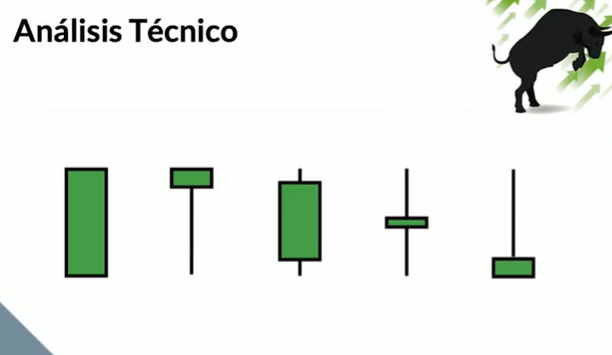
Bull Market (Mercado Optimista)

A diferencia cuando hubo una vela roja quiere decir que hubo mas vendedores que compradores.
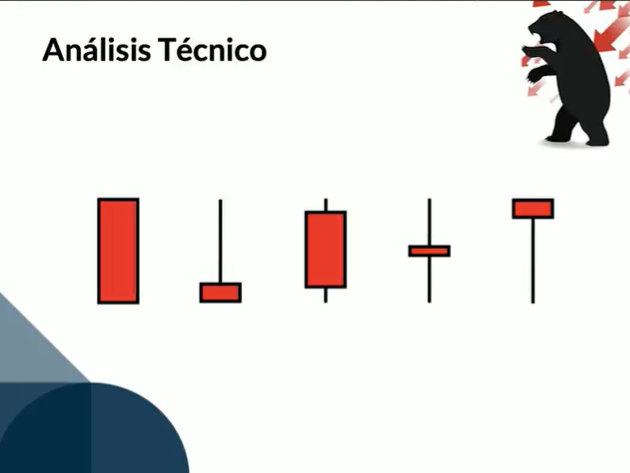
Bear Market (Mercado Pesimista)

1. Vela cilindrica El precio bajo totalmente pesimista. El pronostico es que vaya a la baja.
2. El precio subio mucho pero termina abajo en donde abrio. Menos pesimista.
3. Balance existe un desacuerdo entre compradores y vendedores, posible cambio de mercado.
4. Es muy poca la diferencia, comienza haber una reversion, se preparan para comprar.
5. Apesar de que hubo mas vendedores que compradores, es notable que el precio ya no bajo mas.



In [ ]:
# Example interpretation
first_price = df_btc['close'].iloc[0]
last_price = df_btc['close'].iloc[-1]
price_change = ((last_price - first_price) / first_price) * 100

print("=" * 50)
print("RESUMEN DE PRECIOS")
print("=" * 50)
print(f"\nPrecio inicial: ${first_price:,.2f}")
print(f"Precio final:   ${last_price:,.2f}")
print(f"Cambio total:   {price_change:.2f}%")

RESUMEN DE PRECIOS

Precio inicial: $85,474.35
Precio final:   $74,660.45
Cambio total:   -12.65%


---

## 6. Análisis Estadístico Básico

El análisis estadístico nos ayuda a entender el comportamiento típico de un activo.

### describe()

El método `describe()` genera estadísticas descriptivas que resumen la tendencia central, dispersión y forma de la distribución de los datos. Es una de las primeras funciones que debes ejecutar al explorar un nuevo dataset.

**¿Qué devuelve?**

Para columnas numéricas, `describe()` calcula:

| Estadística | Descripción |
|-------------|-------------|
| `count` | Número de valores no nulos |
| `mean` | Promedio (media aritmética) |
| `std` | Desviación estándar (medida de dispersión) |
| `min` | Valor mínimo |
| `25%` | Primer cuartil (percentil 25) |
| `50%` | Mediana (percentil 50) |
| `75%` | Tercer cuartil (percentil 75) |
| `max` | Valor máximo |

**Parámetros principales:**

| Parámetro | Descripción | Ejemplo |
|-----------|-------------|---------|
| `include` | Tipos de datos a incluir | `'all'`, `[np.number]`, `['object']` |
| `exclude` | Tipos de datos a excluir | `[np.number]` |
| `percentiles` | Lista de percentiles a calcular | `[0.1, 0.5, 0.9]` |

**Sintaxis:**
```python
# Estadísticas básicas (solo columnas numéricas)
df.describe()

# Incluir todas las columnas (numéricas y categóricas)
df.describe(include='all')

# Solo columnas de texto/objeto
df.describe(include=['object'])

# Percentiles personalizados
df.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
```

**Interpretación rápida:**
- Si `mean` ≈ `50%` (mediana): distribución simétrica
- Si `mean` > `50%`: distribución sesgada a la derecha (outliers altos)
- Si `mean` < `50%`: distribución sesgada a la izquierda (outliers bajos)
- `std` grande: alta variabilidad en los datos

[Documentación de describe()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)

In [ ]:
df_btc.describe()

,open,high,low,close,close_thousands,returns
count,90.0000,90.0000,90.0000,90.0000,90.0000,89.0000
mean,79550.0457,80942.2362,77941.0084,79423.3816,79.4234,-0.1067
std,10761.9698,10467.0644,11028.2616,10733.5854,10.7336,3.0055
min,62809.9900,64963.7800,60050.0000,62728.1900,62.7282,-14.0710
25%,68729.7475,70360.1200,67221.5500,68731.9075,68.7319,-1.5096
50%,81431.1800,81744.9000,75678.3700,78716.1100,78.7161,-0.0355
75%,89136.0575,90320.4750,87903.8425,89136.0575,89.1361,1.0435
max,96848.6900,97918.3200,94988.6000,97000.0000,97.0000,12.3148


In [ ]:
# Statistical analysis of returns
returns_stats = df_btc['returns'].describe()

print("=" * 50)
print("ESTADÍSTICAS DE RETORNOS DIARIOS")
print("=" * 50)
print(f"\nNúmero de observaciones: {returns_stats['count']:.0f}")
print(f"Retorno promedio:        {returns_stats['mean']:.4f}%")
print(f"Desviación estándar:     {returns_stats['std']:.4f}%")
print(f"Retorno mínimo:          {returns_stats['min']:.4f}%")
print(f"Retorno máximo:          {returns_stats['max']:.4f}%")
print(f"Mediana (50%):           {returns_stats['50%']:.4f}%")

ESTADÍSTICAS DE RETORNOS DIARIOS

Número de observaciones: 89
Retorno promedio:        -0.1067%
Desviación estándar:     3.0055%
Retorno mínimo:          -14.0710%
Retorno máximo:          12.3148%
Mediana (50%):           -0.0355%


### Identificando los Mejores y Peores Días

Es importante conocer los días de mayor volatilidad para entender el riesgo del activo.

#### nlargest() y nsmallest()

Estos métodos permiten obtener las **n filas** con los valores más grandes o más pequeños de una columna específica. Son muy útiles para identificar extremos en los datos.

| Método | Descripción |
|--------|-------------|
| `nlargest(n, columns)` | Devuelve las `n` filas con los valores **más grandes** |
| `nsmallest(n, columns)` | Devuelve las `n` filas con los valores **más pequeños** |

**Parámetros principales:**

| Parámetro | Descripción | Ejemplo |
|-----------|-------------|---------|
| `n` | Número de filas a devolver | `5`, `10` |
| `columns` | Columna(s) para ordenar | `'price'`, `['col1', 'col2']` |
| `keep` | Qué hacer con empates: `'first'`, `'last'`, `'all'` | `'first'` (default) |

**Sintaxis:**
```python
# Top 5 valores más grandes de una columna
df.nlargest(5, 'columna')

# Top 5 valores más pequeños
df.nsmallest(5, 'columna')

# Seleccionar columnas específicas del resultado
df.nlargest(5, 'returns')[['close', 'returns']]

# Ordenar por múltiples columnas (prioridad de izquierda a derecha)
df.nlargest(5, ['col1', 'col2'])
```

**¿Por qué usar `nlargest`/`nsmallest` en lugar de `sort_values().head()`?**

| Aspecto | `nlargest`/`nsmallest` | `sort_values().head()` |
|---------|------------------------|------------------------|
| Rendimiento | Más rápido (algoritmo optimizado) | Más lento (ordena todo) |
| Memoria | Más eficiente | Crea copia ordenada completa |
| Código | Más conciso y legible | Más verboso |

**Aplicación en análisis financiero:**
- Identificar los días de mayor ganancia/pérdida
- Detectar outliers y eventos extremos
- Analizar la volatilidad del activo

[Documentación de nlargest()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nlargest.html)

[Documentación de nsmallest()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nsmallest.html)

In [ ]:
# Best and worst days
best_days = df_btc.nlargest(5, 'returns')[['close', 'returns']]
worst_days = df_btc.nsmallest(5, 'returns')[['close', 'returns']]

print("=" * 50)
print("TOP 5 MEJORES DÍAS")
print("=" * 50)
display(best_days)

print("\n" + "=" * 50)
print("TOP 5 PEORES DÍAS")
print("=" * 50)
display(worst_days)

TOP 5 MEJORES DÍAS


,close,returns
timestamp,,
2026-02-06,70453.0300,12.3148
2026-03-04,72760.6300,6.5805
2026-02-25,67902.5200,6.0858
2026-03-02,68762.3300,4.5537
2026-01-13,95152.5700,4.3340



TOP 5 PEORES DÍAS


,close,returns
timestamp,,
2026-02-05,62728.1900,-14.0710
2026-01-31,78670.1700,-6.5127
2026-01-29,84570.0000,-5.1407
2026-01-20,88412.0500,-4.4675
2026-02-23,64622.7900,-4.3265


---

## 7. Visualización con Plotly

Las visualizaciones son fundamentales para entender los datos. En esta sección usaremos **Plotly**, una librería que genera gráficos **interactivos**: puedes hacer zoom, hover para ver valores exactos, y seleccionar rangos directamente en el gráfico.

Usaremos principalmente **Plotly Express** (`px`), la API de alto nivel con sintaxis declarativa. Para el gráfico de velas (candlestick), usaremos **Plotly Graph Objects** (`go`), ya que Plotly Express no incluye este tipo de gráfico.

### ¿Qué gráfico usar?

| Quiero ver... | Tipo de gráfico | Función |
|---------------|-----------------|---------|
| Evolución en el tiempo | Line chart | `px.line()` |
| Precios OHLC detallados | Candlestick | `go.Candlestick()` |
| Valores por período (positivos/negativos) | Bar chart | `px.bar()` |
| Distribución de una variable | Histograma | `px.histogram()` |

### 7.1 Line Chart — Evolución del Precio

Un **line chart** (gráfico de línea) conecta puntos de datos con una línea continua. Es el gráfico más utilizado para visualizar **tendencias a lo largo del tiempo** porque permite identificar rápidamente si un valor sube, baja o se mantiene estable.

[Documentación de px.line()](https://plotly.com/python/line-charts/)

In [ ]:
df_btc_reset = df_btc.reset_index()  # reset index to use timestamp as a regular column (required by px)

fig = px.line(
    df_btc_reset,
    x='timestamp',                                        # column for the horizontal axis
    y='close',                                            # column for the vertical axis
    title='Bitcoin - Closing Price (90 days)',
    labels={'timestamp': 'Date', 'close': 'Price (USD)'}  # rename axis labels
)

fig.update_layout(
    template='plotly_dark',   # visual theme (dark background)
    hovermode='x unified',   # hover shows all values at same x position
    width=1400,
    height=600
)

fig.update_yaxes(tickprefix='$', tickformat=',.0f')  # '$' prefix, comma separator, no decimals

fig.show()

Antes de leer la interpretación, observa el gráfico durante unos segundos. ¿Qué patrones puedes identificar?

<details>
<summary><strong>Haz clic para ver la interpretación</strong></summary>

**¿Qué nos muestra este gráfico?**

- La **tendencia general** del precio de BTC en los últimos 90 días: ¿subió, bajó o se mantuvo lateral?
- Los **períodos de alta volatilidad** se ven como movimientos bruscos (subidas o caídas pronunciadas)

**¿Qué buscar?**

- **Dirección general**: ¿La línea va hacia arriba (tendencia alcista) o hacia abajo (bajista)?
- **Puntos de máximo y mínimo**: ¿En qué fechas ocurrieron?
- **Usa el hover** para ver el precio exacto de cualquier día

</details>

### 7.2 Candlestick — Gráfico de Velas (OHLC)

El **candlestick** (gráfico de velas) es el gráfico más utilizado en trading. Cada "vela" representa un período de tiempo y muestra 4 valores: **Open** (apertura), **High** (máximo), **Low** (mínimo) y **Close** (cierre).

**Anatomía de una vela:**
- **Cuerpo**: Diferencia entre apertura y cierre. Verde = el precio subió (close > open). Rojo = el precio bajó (close < open)
- **Mechas** (wicks): Líneas delgadas que muestran el máximo y mínimo del período

**Nota:** Plotly Express no incluye candlestick, por lo que usamos `plotly.graph_objects` (`go`). Esto es común: a veces la API de alto nivel no cubre todo y necesitas bajar un nivel.

[Documentación de go.Candlestick()](https://plotly.com/python/candlestick-charts/)

In [ ]:
fig = go.Figure(data=[go.Candlestick(
    x=df_btc.index,                          # dates for the x-axis
    open=df_btc['open'],                     # opening prices
    high=df_btc['high'],                     # highest prices
    low=df_btc['low'],                       # lowest prices
    close=df_btc['close'],                   # closing prices
    increasing_line_color=COLORS['green'],   # color for bullish candles (price went up)
    decreasing_line_color=COLORS['red']      # color for bearish candles (price went down)
)])

fig.update_layout(
    title='Bitcoin - Candlestick Chart (90 days)',
    yaxis_title='Price (USD)',
    xaxis_title='Date',
    template='plotly_dark',
    xaxis_rangeslider_visible=False,
    width=1400,
    height=600
)

fig.update_yaxes(tickprefix='$', tickformat=',.0f')

fig.show()

Antes de leer la interpretación, observa el gráfico durante unos segundos. ¿Qué patrones puedes identificar?

<details>
<summary><strong>Haz clic para ver la interpretación</strong></summary>

**¿Qué nos muestra este gráfico?**

- Cada vela = **1 día**. Vela verde = el precio subió ese día. Vela roja = el precio bajó
- Las **mechas** muestran el rango intradiario: el precio máximo y mínimo que se alcanzó durante el día
- Velas con **cuerpo grande** = movimiento decisivo del mercado. **Mechas largas** = indecisión (el precio exploró pero volvió)

**¿Qué buscar?**

- **Secuencias de velas del mismo color**: indican una tendencia (alcista o bajista)
- **Velas con mechas largas**: señalan rechazo de precio en ciertos niveles
- **Haz hover** sobre cualquier vela para ver los 4 valores OHLC exactos

</details>

### 7.3 Bar Chart — Retornos Diarios

Un **bar chart** (gráfico de barras) muestra valores como barras individuales. Es ideal para **comparar valores discretos** o visualizar la magnitud y dirección de cambios. En este caso, lo usaremos para ver los retornos diarios coloreados por positivo (verde) y negativo (rojo).

[Documentación de px.bar()](https://plotly.com/python/bar-charts/)

In [ ]:
df_plot = df_btc.reset_index().dropna(subset=['returns']).copy()
df_plot['direction'] = df_plot['returns'].apply(lambda x: 'Positive' if x >= 0 else 'Negative')

fig = px.bar(
    df_plot,
    x='timestamp',                                # column for the horizontal axis (dates)
    y='returns',                                  # column for bar height (return percentage)
    color='direction',                            # column that determines each bar's color
    color_discrete_map={                          # map category values to specific colors
        'Positive': COLORS['green'],
        'Negative': COLORS['red']
    },
    title='Bitcoin - Daily Returns (%)',
    labels={'timestamp': 'Date', 'returns': 'Return (%)'}
)

fig.update_layout(
    template='plotly_dark',
    hovermode='x unified',
    width=1400,
    height=600
)

fig.show()

Antes de leer la interpretación, observa el gráfico durante unos segundos. ¿Qué patrones puedes identificar?

<details>
<summary><strong>Haz clic para ver la interpretación</strong></summary>

**¿Qué nos muestra este gráfico?**

- La **magnitud y dirección** de cada retorno diario: barras grandes = días de mucho movimiento
- El **balance visual** entre días positivos (verde) y negativos (rojo)
- Los **períodos de alta volatilidad** se ven como clusters de barras grandes en ambas direcciones

**¿Qué buscar?**

- **¿Domina algún color?** Si hay más verde que rojo, el mercado tuvo sesgo alcista en ese período (y viceversa)
- **¿Hay clusters de barras grandes?** Indican períodos de alta volatilidad donde el mercado se movió mucho
- **Barras aisladas muy grandes**: eventos extremos que vale la pena investigar

</details>

### 7.4 Histograma — Distribución de Retornos

Un **histograma** divide los datos en intervalos (bins) y cuenta cuántos valores caen en cada uno. Es la herramienta principal para visualizar la **distribución** de una variable: ¿la mayoría de los valores se concentran en un rango? ¿Hay valores extremos?

Además, usaremos `add_vline()` para agregar líneas verticales de referencia (media y cero).

[Documentación de px.histogram()](https://plotly.com/python/histograms/)

In [ ]:
returns_clean = df_btc['returns'].dropna()

fig = px.histogram(
    df_btc.dropna(subset=['returns']),
    x='returns',                                           # column to plot the distribution of
    nbins=30,                                              # number of bins (intervals)
    title='Bitcoin - Distribution of Daily Returns',
    labels={'returns': 'Return (%)', 'count': 'Frequency'},
    color_discrete_sequence=[COLORS['primary']]            # list of colors for the bars
)

fig.add_vline(
    x=0, line_dash='dash', line_color=COLORS['red'],      # vertical line at zero
    annotation_text='Zero'
)
fig.add_vline(
    x=returns_clean.mean(), line_color=COLORS['green'],   # vertical line at mean
    annotation_text=f"Mean ({returns_clean.mean():.2f}%)"
)

fig.update_layout(
    template='plotly_dark',
    width=1400,
    height=600,
    showlegend=False
)

fig.show()

Antes de leer la interpretación, observa el gráfico durante unos segundos. ¿Qué patrones puedes identificar?

<details>
<summary><strong>Haz clic para ver la interpretación</strong></summary>

**¿Qué nos muestra este gráfico?**

- La **mayoría de los retornos** se concentran cerca de 0%, formando la parte alta de la distribución
- La distribución tiene forma aproximada de **campana** (distribución normal), lo cual es esperado en retornos financieros
- Las **colas** (extremos izquierdo y derecho) muestran días de retornos extremos: poco frecuentes pero significativos

**¿Qué buscar?**

- **¿Es simétrica?** Si la media (línea verde) está cerca de 0 (línea roja), el mercado no tuvo un sesgo claro
- **¿Tiene colas pesadas?** Si hay barras alejadas del centro, existe riesgo de eventos extremos
- **Conecta con la sección 6**: compara lo que ves aquí con las estadísticas de `describe()` — la media, desviación estándar, min y max deberían coincidir con lo que muestra el histograma

</details>

---

## 8. Ejercicio Guiado: Filtrado y Selección

---
### 🎯 EJERCICIO: Análisis de Retornos Extremos de BTC

---

**Objetivo**: Practicar filtrado, selección e indexación con los datos de BTC que ya tenemos.

**Tareas**:
1. Filtrar los días donde el retorno fue mayor a 3%
2. Filtrar los días donde el retorno fue menor a -3%
3. Usar `iloc` para seleccionar los primeros 10 registros
4. Usar `loc` para seleccionar solo las columnas 'close' y 'returns'
5. Contar cuántos días tuvieron retornos positivos vs negativos
6. Crear un gráfico de barras con `px.bar()` que muestre los retornos extremos (> 3% y < -3%) coloreados por dirección (positivo/negativo)

**Hints**:
- Utiliza el dataframe llamado `df_btc` para resolver las tareas
- Usa condiciones booleanas: `df_btc[df_btc['returns'] > 3]`
- Para contar, puedes usar `sum()` sobre una condición booleana
- Para el gráfico, combina los días extremos con `pd.concat()` y usa el parámetro `color` de `px.bar()`

---

In [ ]:
# Your code here - Task 1: Filter days with return > 3%
df_btc[df_btc['returns'] > 3]

,open,high,low,close,currency,close_thousands,returns
timestamp,,,,,,,
2025-12-19,85505.1400,89200.0000,85225.0000,88195.6200,USD,88.1956,3.1837
2026-01-13,91200.0000,95600.0500,91000.0000,95152.5700,USD,95.1526,4.3340
2026-02-06,62809.9900,71546.4800,60050.0000,70453.0300,USD,70.4530,12.3148
2026-02-13,66140.8000,69300.2800,65758.8100,68757.9400,USD,68.7579,3.8960
2026-02-25,64039.4300,70000.0000,63918.5000,67902.5200,USD,67.9025,6.0858
2026-03-02,65785.2100,70072.1300,65258.9400,68762.3300,USD,68.7623,4.5537
2026-03-04,68297.9200,74051.4400,67413.4500,72760.6300,USD,72.7606,6.5805
2026-03-09,66005.5000,69500.0000,65871.4300,68405.0000,USD,68.4050,3.7005


In [ ]:
# Your code here - Task 2: Filter days with return < -3%
df_btc[df_btc['returns'] < -3]

,open,high,low,close,currency,close_thousands,returns
timestamp,,,,,,,
2026-01-20,92705.0000,92807.5700,87839.0500,88412.0500,USD,88.4121,-4.4675
2026-01-29,89148.6600,89148.6600,83272.0100,84570.0000,USD,84.5700,-5.1407
2026-01-31,84150.0600,84150.0600,75688.0000,78670.1700,USD,78.6702,-6.5127
2026-02-03,78712.3000,79127.1400,72938.0000,75673.3300,USD,75.6733,-3.9216
2026-02-04,75671.4600,76911.4900,71750.0000,73000.0000,USD,73.0000,-3.5327
2026-02-05,72956.9000,73121.5100,62200.0000,62728.1900,USD,62.7282,-14.0710
2026-02-23,67579.8300,67579.8300,63885.3600,64622.7900,USD,64.6228,-4.3265
2026-03-06,70866.4500,71418.0300,67770.4500,68150.1400,USD,68.1501,-3.8434


In [ ]:
# Your code here - Task 3: Select first 10 records with iloc
df_btc.iloc[:10]

,open,high,low,close,currency,close_thousands,returns
timestamp,,,,,,,
2025-12-18,86156.9700,89781.0700,84652.0000,85474.3500,USD,85.4744,NaN
2025-12-19,85505.1400,89200.0000,85225.0000,88195.6200,USD,88.1956,3.1837
2025-12-20,88100.0000,88523.7500,87942.1600,88436.9700,USD,88.4370,0.2737
2025-12-21,88437.9800,88945.3000,87640.7100,88621.7900,USD,88.6218,0.2090
2025-12-22,88621.7900,90438.9700,87925.4400,88477.9500,USD,88.4779,-0.1623
2025-12-23,88477.9500,88962.1900,86654.7100,87339.2100,USD,87.3392,-1.2870
2025-12-24,87500.0000,88760.0900,86500.0000,87596.0100,USD,87.5960,0.2940
2025-12-25,87596.0100,88520.1400,86951.5000,87148.7000,USD,87.1487,-0.5107
2025-12-26,87170.8800,89439.9100,86704.9100,87362.9400,USD,87.3629,0.2458


In [ ]:
# Your code here - Task 4: Select columns with loc (only 'close' and 'returns')
df_btc.loc[:, 'close':'returns']

,close,currency,close_thousands,returns
timestamp,,,,
2025-12-18,85474.3500,USD,85.4744,NaN
2025-12-19,88195.6200,USD,88.1956,3.1837
2025-12-20,88436.9700,USD,88.4370,0.2737
2025-12-21,88621.7900,USD,88.6218,0.2090
2025-12-22,88477.9500,USD,88.4779,-0.1623
...,...,...,...,...
2026-03-13,70929.4700,USD,70.9295,0.4444
2026-03-14,71244.3300,USD,71.2443,0.4439
2026-03-15,72815.5000,USD,72.8155,2.2053


In [ ]:
# Your code here - Task 5: Count positive vs negative days
int(df_btc[df_btc['returns'] > 3]['returns'].count()), int(df_btc[df_btc['returns'] < -3]['returns'].count())

(8, 8)

In [ ]:
# Your code here - Task 6: Create a bar chart of extreme returns (> 3% and < -3%)
xt_positive = df_btc[df_btc['returns'] > 3]
xt_negative = df_btc[df_btc['returns'] < -3]
xt_days = pd.concat([xt_positive, xt_negative]).sort_index().reset_index()
xt_days['direction'] = xt_days['returns'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

fig = px.bar(
    xt_days,
    x='timestamp',
    y='returns',
    title='Extreme returns daily',
    labels={'timestamp': 'Date', 'returns': 'Return %'},
    color='direction',
    color_discrete_map={'Negative': COLORS['red'], 'Positive': COLORS['green']}
)

fig.update_layout(
    template='plotly_dark',
    hovermode='x unified'
)

fig.show()

### Solución

In [ ]:
#@title Tarea 1: Haz clic para ver la solucion { display-mode: "form" }
#@markdown > **Nota:** Intenta resolver el ejercicio antes de ver esta solución.
# =============================================================================
# ✅ SOLUCIÓN - Tarea 1: Filtrar días con retorno > 3%
# =============================================================================
extreme_positive_days = df_btc[df_btc['returns'] > 3]

print(f"Días con retorno mayor a 3%: {len(extreme_positive_days)}")
display(extreme_positive_days[['close', 'returns']])

Días con retorno mayor a 3%: 8


,close,returns
timestamp,,
2025-12-19,88195.6200,3.1837
2026-01-13,95152.5700,4.3340
2026-02-06,70453.0300,12.3148
2026-02-13,68757.9400,3.8960
2026-02-25,67902.5200,6.0858
2026-03-02,68762.3300,4.5537
2026-03-04,72760.6300,6.5805
2026-03-09,68405.0000,3.7005


In [ ]:
#@title Tarea 2: Haz clic para ver la solucion { display-mode: "form" }
#@markdown > **Nota:** Intenta resolver el ejercicio antes de ver esta solución.
# =============================================================================
# ✅ SOLUCIÓN - Tarea 2: Filtrar días con retorno < -3%
# =============================================================================
extreme_negative_days = df_btc[df_btc['returns'] < -3]

print(f"Días con retorno menor a -3%: {len(extreme_negative_days)}")
display(extreme_negative_days[['close', 'returns']])

Días con retorno menor a -3%: 8


,close,returns
timestamp,,
2026-01-20,88412.0500,-4.4675
2026-01-29,84570.0000,-5.1407
2026-01-31,78670.1700,-6.5127
2026-02-03,75673.3300,-3.9216
2026-02-04,73000.0000,-3.5327
2026-02-05,62728.1900,-14.0710
2026-02-23,64622.7900,-4.3265
2026-03-06,68150.1400,-3.8434


In [ ]:
#@title Tarea 3: Haz clic para ver la solucion { display-mode: "form" }
#@markdown > **Nota:** Intenta resolver el ejercicio antes de ver esta solución.
# =============================================================================
# ✅ SOLUCIÓN - Tarea 3: Usar iloc para seleccionar primeros 10 registros
# =============================================================================
first_10 = df_btc.iloc[:10]

print("Primeros 10 registros con iloc:")
display(first_10)

Primeros 10 registros con iloc:


,open,high,low,close,currency,close_thousands,returns
timestamp,,,,,,,
2025-12-18,86156.9700,89781.0700,84652.0000,85474.3500,USD,85.4744,NaN
2025-12-19,85505.1400,89200.0000,85225.0000,88195.6200,USD,88.1956,3.1837
2025-12-20,88100.0000,88523.7500,87942.1600,88436.9700,USD,88.4370,0.2737
2025-12-21,88437.9800,88945.3000,87640.7100,88621.7900,USD,88.6218,0.2090
2025-12-22,88621.7900,90438.9700,87925.4400,88477.9500,USD,88.4779,-0.1623
2025-12-23,88477.9500,88962.1900,86654.7100,87339.2100,USD,87.3392,-1.2870
2025-12-24,87500.0000,88760.0900,86500.0000,87596.0100,USD,87.5960,0.2940
2025-12-25,87596.0100,88520.1400,86951.5000,87148.7000,USD,87.1487,-0.5107
2025-12-26,87170.8800,89439.9100,86704.9100,87362.9400,USD,87.3629,0.2458


In [ ]:
#@title Tarea 4: Haz clic para ver la solucion { display-mode: "form" }
#@markdown > **Nota:** Intenta resolver el ejercicio antes de ver esta solución.
# =============================================================================
# ✅ SOLUCIÓN - Tarea 4: Usar loc para seleccionar columnas específicas
# =============================================================================
selected_columns = df_btc.loc[:, ['close', 'returns']]

print("Selección de columnas 'close' y 'returns' con loc:")
display(selected_columns.head(10))

Selección de columnas 'close' y 'returns' con loc:


,close,returns
timestamp,,
2025-12-18,85474.3500,NaN
2025-12-19,88195.6200,3.1837
2025-12-20,88436.9700,0.2737
2025-12-21,88621.7900,0.2090
2025-12-22,88477.9500,-0.1623
2025-12-23,87339.2100,-1.2870
2025-12-24,87596.0100,0.2940
2025-12-25,87148.7000,-0.5107
2025-12-26,87362.9400,0.2458


In [ ]:
#@title Tarea 5: Haz clic para ver la solucion { display-mode: "form" }
#@markdown > **Nota:** Intenta resolver el ejercicio antes de ver esta solución.
# =============================================================================
# ✅ SOLUCIÓN - Tarea 5: Contar días positivos vs negativos
# =============================================================================
positive_days = (df_btc['returns'] > 0).sum()
negative_days = (df_btc['returns'] < 0).sum()
total_days = df_btc['returns'].dropna().count()

print("=" * 50)
print("DISTRIBUCIÓN DE RETORNOS")
print("=" * 50)
print(f"\nDías positivos: {positive_days} ({positive_days/total_days*100:.1f}%)")
print(f"Días negativos: {negative_days} ({negative_days/total_days*100:.1f}%)")

DISTRIBUCIÓN DE RETORNOS

Días positivos: 42 (47.2%)
Días negativos: 47 (52.8%)


In [ ]:
#@title Tarea 6: Haz clic para ver la solucion { display-mode: "form" }
#@markdown > **Nota:** Intenta resolver el ejercicio antes de ver esta solución.
# =============================================================================
# ✅ SOLUCIÓN - Tarea 6: Gráfico de barras con retornos extremos
# =============================================================================

# Filter extreme positive and negative days
extreme_positive = df_btc[df_btc['returns'] > 3].copy()
extreme_negative = df_btc[df_btc['returns'] < -3].copy()

# Combine both into a single DataFrame
extreme_days = pd.concat([extreme_positive, extreme_negative])

# Prepare data for plotting (reset index + add direction column)
df_extreme_plot = extreme_days.reset_index()
df_extreme_plot['direction'] = df_extreme_plot['returns'].apply(
    lambda x: 'Positive (> 3%)' if x > 0 else 'Negative (< -3%)'
)

# Create bar chart
fig = px.bar(
    df_extreme_plot,
    x='timestamp',
    y='returns',
    color='direction',
    color_discrete_map={
        'Positive (> 3%)': COLORS['green'],
        'Negative (< -3%)': COLORS['red']
    },
    title='Bitcoin - Extreme Daily Returns (> 3% and < -3%)',
    labels={'timestamp': 'Date', 'returns': 'Return (%)'}
)

fig.update_layout(
    template='plotly_dark',
    hovermode='x unified',
    width=1400,
    height=600
)

fig.show()

In [ ]:
# @title
API_K = "QCmF4Sr_X_nape8GPCl8JZ2vF9PBAI2c"

---

## 9. Ejercicio Independiente

---
### 💪 EJERCICIO: Análisis de Volumen de Trading de Bitcoin

---

**Objetivo**: Practicar limpieza de datos, filtrado y visualización usando `df_from_csv` (el DataFrame que cargamos en la sección 2.3).

**Tareas**:
1. Explorar `df_from_csv` con `info()` y `dtypes` para entender su estructura
2. Limpiar los datos:
   - Convertir la columna `Date` a datetime con `pd.to_datetime()`
   - Identificar valores nulos con `isnull().sum()`
   - Eliminar filas con nulos en `btc_trade_volume` usando `dropna(subset=...)`
3. Filtrar los datos:
   - Usar `loc` para seleccionar solo las columnas `Date` y `btc_trade_volume`
   - Filtrar filas donde `btc_trade_volume > 0`
4. Crear un histograma de `btc_trade_volume` con `px.histogram()`:
   - Usa `nbins=30`
   - Agrega un título descriptivo y labels para los ejes
   - Usa `template='plotly_dark'`

**Hints**:
- `df_from_csv` ya está cargado en memoria desde la sección 2.3
- Para dropna en una columna específica: `df.dropna(subset=['nombre_columna'])`
- Para el histograma, revisa la sección 7.4 como referencia de sintaxis

[Documentación de px.histogram()](https://plotly.com/python/histograms/)

---

In [150]:
# Your code here - Task 1: Explore df_from_csv with info() and dtypes
#Explore NVIDIA stock
import requests
url = f"https://api.massive.com/v2/aggs/ticker/NVDA/range/1/month/2024-01-01/2024-12-31?apiKey={API_K}"
api_data = requests.get(url).json()

df_NVDA = pd.DataFrame(api_data['results'])

print(f"dtypes\n{df_NVDA.dtypes}")
df_NVDA.info()

dtypes
v     float64
vw    float64
o     float64
c     float64
h     float64
l     float64
t       int64
n       int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   v       10 non-null     float64
 1   vw      10 non-null     float64
 2   o       10 non-null     float64
 3   c       10 non-null     float64
 4   h       10 non-null     float64
 5   l       10 non-null     float64
 6   t       10 non-null     int64  
 7   n       10 non-null     int64  
dtypes: float64(6), int64(2)
memory usage: 772.0 bytes


In [151]:
# Your code here - Task 2: Convert Date to datetime, identify and handle null values
df_NVDA['t'] = pd.to_datetime(df_NVDA['t'], unit='ms')

df_NVDA = df_NVDA.rename(columns={'c': 'close', 'o': 'open', 'h': 'high', 'l': 'low', 'v': 'volume','t': 'datetime'})

df_NVDA.set_index('datetime', inplace=True)

print(df_NVDA.isnull().sum())

df_NVDA.dropna(inplace=True)

volume    0
vw        0
open      0
close     0
high      0
low       0
n         0
dtype: int64


In [155]:
# Your code here - Task 3: Select columns with loc and filter rows where btc_trade_volume > 0
nvidia_trade_volume = df_NVDA[df_NVDA['volume'] > 0]
nvidia_trade_volume.loc[:, ['volume']]

,volume
datetime,
2024-03-01 05:00:00,12149220670.0000
2024-04-01 04:00:00,10074179110.0000
2024-05-01 04:00:00,9647970760.0000
2024-06-01 04:00:00,7442538522.0000
2024-07-01 04:00:00,6407092755.0000
2024-08-01 04:00:00,8105367559.0000
2024-09-01 04:00:00,6272711021.0000
2024-10-01 04:00:00,5628704792.0000
2024-11-01 04:00:00,4498075137.0000


In [158]:
# Your code here - Task 4: Create a histogram of btc_trade_volume with px.histogram()
# Hint: px.histogram(df, x='column_name', nbins=30, title='...', labels={...})

fig = px.histogram(
    nvidia_trade_volume,
    x='volume',
    nbins=30,
    title='NVIDIA - Distribution of Trade Volume',
    labels={'volume': 'Trade Volume', 'count': 'Frequency'},
    template='plotly_dark'
)

fig.show()

---

## 10. Resumen

### ¿Qué aprendimos hoy?

- **DataFrames**: Crear DataFrames desde diccionarios, listas, CSV y APIs
- **Indexación**: Usar `loc` (por etiqueta) e `iloc` (por posición)
- **Filtrado**: Seleccionar datos con condiciones booleanas
- **APIs**: Obtener datos históricos OHLC desde la API de Binance US
- **Manejo de errores**: Usar `try/except` y `timeout` en peticiones HTTP para evitar que el programa se cuelgue o falle silenciosamente
- **Limpieza de datos**: Verificar tipos (`dtypes`, `info`), convertir tipos (`astype`), manejar fechas (`to_datetime`) y valores nulos (`fillna`, `dropna`)
- **Persistencia**: Guardar datos limpios a CSV con `to_csv()` y cargarlos con `read_csv()` para no depender de la API
- **Resampling**: Cambiar la frecuencia temporal de datos OHLC con `resample()` (diario → semanal)
- **Retornos**: Calcular cambios porcentuales con `pct_change()`
- **Estadísticas**: Analizar datos con `describe()`, `nlargest()`, `nsmallest()`
- **Visualización**: Crear gráficos interactivos con Plotly (line, candlestick, bar, histogram)

### Funciones y métodos clave:

```python
# Crear DataFrame
pd.DataFrame(data)

# Indexación
df.loc[filas, columnas]     # Por etiqueta
df.iloc[filas, columnas]    # Por posición

# Filtrado
df[df['columna'] > valor]

# Verificar datos
df.dtypes                   # Tipos de datos
df.info()                   # Información completa
df.isnull().sum()           # Valores nulos

# Manejo de errores en requests
requests.get(url, timeout=10)    # Timeout para evitar esperas infinitas
response.raise_for_status()      # Lanza excepción si hay error HTTP

# Limpieza de datos
df.astype(float)                    # Convertir tipos
pd.to_datetime(col, unit='ms')     # Convertir a fecha
df.set_index('col')                 # Establecer índice

# Persistencia de datos
df.to_csv('archivo.csv')                                          # Guardar a CSV
pd.read_csv('archivo.csv', index_col='col', parse_dates=True)     # Leer desde CSV

# Manejo de nulos
df.fillna(valor)            # Rellenar
df.dropna()                 # Eliminar

# Resampling
df.resample('W').agg({'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last'})

# Retornos
df['col'].pct_change() * 100

# Estadísticas
df.describe()
df.nlargest(n, 'col')
df.nsmallest(n, 'col')

# Visualización con Plotly
px.line(df, x='col_x', y='col_y')          # Línea temporal
go.Candlestick(x=, open=, high=, low=, close=)  # Velas OHLC
px.bar(df, x='col_x', y='col_y', color=)   # Barras
px.histogram(df, x='col', nbins=30)         # Distribución
```

---

### Recursos Adicionales

- [Pandas - Indexación y Selección](https://pandas.pydata.org/docs/user_guide/indexing.html)
- [Pandas - Cálculo de Retornos](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pct_change.html)
- [Pandas - to_csv()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html)
- [Pandas - resample()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html)
- [Pandas - Documentación General](https://pandas.pydata.org/docs/)
- [Requests - Timeouts](https://requests.readthedocs.io/en/latest/user/quickstart/#timeouts)
- [Requests - Errores y Excepciones](https://requests.readthedocs.io/en/latest/user/quickstart/#errors-and-exceptions)
- [Plotly Express - Documentación](https://plotly.com/python/plotly-express/)
- [Plotly - Candlestick Charts](https://plotly.com/python/candlestick-charts/)
- [Binance.US API - Documentación](https://docs.binance.us/)